
# 🧠 MRI → Python → Nilearn: From 3D volumes to a DLPFC ROI mean (SimNIBS E‑field magnitude)

*Goal*: Learn just enough **Python** and **nilearn** to:

1. Load a folder of NIfTI (`.nii`/`.nii.gz`) volumes containing **SimNIBS E‑field magnitude** values (|E|) per voxel (typically in GM).
2. Define a spherical **Region of Interest (ROI)** centered on an **MNI coordinate** approximating the **DLPFC**.
3. Extract the **mean E‑field magnitude** within that ROI **for each subject** and save a tidy **CSV** file.
4. Perform quick **visual quality control** (QC) to verify alignment and ROI placement.

> **Important**: This tutorial assumes your volumes are **already in MNI space**. If your images are in native space, you must first register or normalize them to MNI, or alternatively transform the ROI into native space. We include tips below, but do not cover full registration workflows here.

---

## What you will learn

- What a **NIfTI** image is (data + spatial affine).
- The difference between **image space** (voxel grid) and **world space** (coordinates in mm, e.g., **MNI**).
- How to create a **spherical ROI** using `NiftiSpheresMasker` and compute statistics inside it.
- How to loop over multiple files and export results.
- How to make simple plots for QC.

---

## Prerequisites

- You have one NIfTI file per subject with E‑field magnitude values (|E|). These are obtained by setting `fields = e` in the simulation config file.
- If you don't want to provide a grey matter mask, then `tissues_in_nifti` field must have been set to `2` in the simulation config file.
- This script expects the volumes to be in MNI space so the `map_to_mni` field of the simulation config file must have been set to `True`.



## Using this notebook in VS Code (5 quick steps)

1. Open this notebook in the **VS Code editor**.
2. In the top-right of the notebook, click the **kernel selector**, then **Python Environments** -> **Create Python Environment** -> **Quick Create** (which should use **venv**).
3. In a terminal, run `source ./.venv/bin/activate && pip install nilearn matplotlib`.
4. Run cells from top to bottom by pressing **Shift+Enter** (or the ▶️ Run button on each cell). If the notebook has not already set the default environment, you will be prompted to select one, choose the one we just created.
5. If a cell errors, read the message; re-run the previous cells or adjust the **Configuration** section.



## A 5‑minute Python crash course (only what you need)

- **Variables** hold values:
  ```python
  radius_mm = 10
  center_mni = (-38, 44, 26)
  ```
- **Lists** hold multiple items:
  ```python
  centers = [(-38, 44, 26), (38, 44, 26)]  # left & right DLPFC
  ```
- **Functions** package reusable steps:
  ```python
  def add(x, y):
      return x + y
  ```
- **Loops** repeat actions over items:
  ```python
  for x in [1, 2, 3]:
      print(x)
  ```
- **Libraries** add capabilities (we’ll use `numpy`, `pandas`, `nibabel`, and `nilearn`).

That’s enough to start!


In [1]:

# ✅ Imports & version check
import os, sys, glob, math
import numpy as np
import pandas as pd
import nibabel as nib
import matplotlib.pyplot as plt

from nilearn import image, plotting, datasets
from nilearn.maskers import NiftiSpheresMasker

print("Python:", sys.version.split()[0])
print("nilearn:", __import__('nilearn').__version__)
print("nibabel:", nib.__version__)
print("numpy:", np.__version__)
print("pandas:", pd.__version__)


Python: 3.14.0
nilearn: 0.12.1
nibabel: 5.3.2
numpy: 2.3.5
pandas: 2.3.3



## Configuration (edit this cell!)

Fill in the paths and parameters below. You can start with the defaults and adjust later.

- `DATA_DIR`: folder containing your subject NIfTI files.
- `FILE_GLOB`: pattern that matches your files (e.g., `*_Efield_mag.nii.gz`).
- `DLPFC_CENTER_MNI`: the MNI coordinate (in millimeters) for the DLPFC seed. Common choices for **left DLPFC** are around **(-38, 44, 26)**; for **right DLPFC**, around **(38, 44, 26)**. Use what your team and literature justify.
- `SPHERE_RADIUS_MM`: radius of the spherical ROI in **millimeters**. Typical values: 6–10 mm.
- `IGNORE_ZEROS_IN_ROI`: if `True`, zeros inside the ROI will be treated as missing (ignored) when computing the mean—useful when only GM voxels carry non-zero values.
- `OPTIONAL_GM_MASK`: path to a GM mask in the same space as your E-field images (leave `None` to skip). This will restrict the ROI to GM if provided.
- `SMOOTHING_FWHM`: set to a positive number (e.g., `3.0`) to lightly smooth before ROI extraction; `None` leaves data untouched.


In [ ]:
# 🔧 EDIT ME: Paths and parameters
DATA_DIR = "/Users/guillaume.coudriet/COLLAB_Almeria_local/FRONTLAB-SimNIBS-pipeline/outputs/ernie/simulations/simulation_tdcs_simulation_example_a5e52e56/mni_volumes"  # e.g., r"C:/Users/you/efields" or "/home/you/efields"
FILE_GLOB = "*scalar_MNI_magnE.nii*"  # matches .nii or .nii.gz

# Choose your DLPFC seed (in MNI mm). Start with left DLPFC.
DLPFC_CENTER_MNI = (-37, 41, 22)  # change to (37, 41, 22) for right DLPFC
SPHERE_RADIUS_MM = 10  # mm

# Behavior in averaging
IGNORE_ZEROS_IN_ROI = True # This is important if the E-field was only computed in grey matter (GM), to avoid averaging in zeros outside GM
OPTIONAL_GM_MASK = None  # e.g., r"./masks/GM_mask_MNI.nii.gz" or leave as None, only useful if GM was not the only tissue the E-field was computed in
SMOOTHING_FWHM = None  # e.g., 3.0 for light smoothing

# Output file
OUTPUT_CSV = "efield_DLPFC_roi_means.csv"

# --- No edits needed below ---
DATA_DIR = os.path.abspath(DATA_DIR)
# print("Data folder:", DATA_DIR)
print("Looking for files matching:\n\t", os.path.join(DATA_DIR, FILE_GLOB))
files = sorted(glob.glob(os.path.join(DATA_DIR, FILE_GLOB)))
print(f"Found {len(files)} file(s)")
if files:
    print("Example:", os.path.basename(files[0]))
else:
    print("⚠️ No files matched. Check DATA_DIR and FILE_GLOB.")


Looking for files matching:
	 /Users/guillaume.coudriet/COLLAB_Almeria_local/FRONTLAB-SimNIBS-pipeline/outputs/ernie/simulations/simulation_tdcs_simulation_example_a5e52e56/mni_volumes/*scalar_MNI_magnE.nii*
Found 1 file(s)
Example: ernie_TDCS_1_scalar_MNI_magnE.nii.gz



## NIfTI 101: data and affine

A **NIfTI** image contains:

- A **3D (or 4D) array** of voxel values (our E‑field magnitude).
- An **affine matrix** that maps **voxel indices** → **world coordinates** (millimeters in **MNI space** if normalized).

Below we load one subject and inspect shape, voxel size, and affine. We’ll also try to load an **MNI template** for quick visual checks.


In [3]:

# Load one example image (first in the list)
if not files:
    raise FileNotFoundError("No files found. Please adjust DATA_DIR and FILE_GLOB above and re-run.")

example_img_path = files[0]
img = image.load_img(example_img_path)
print("Example file:", example_img_path)
print("Shape:", img.shape)
print("Affine:\n", img.affine)

# Attempt to load an MNI template for plotting/QC
mni_template = None
try:
    mni_template = datasets.load_mni152_template(resolution=2)  # 2mm is fine for QC
    print("Loaded MNI152 template (2mm)")
except Exception as e:
    print("Could not load MNI template:", e)

# Basic summary statistics for the example image
import numpy as np
img_data = img.get_fdata(dtype=float)
finite_mask = np.isfinite(img_data)
print("Data stats (finite voxels only): min=%.4g  median=%.4g  max=%.4g" % (
    np.nanmin(img_data[finite_mask]), np.nanmedian(img_data[finite_mask]), np.nanmax(img_data[finite_mask])
))


Example file: /Users/guillaume.coudriet/COLLAB_Almeria_local/FRONTLAB-SimNIBS-pipeline/outputs/ernie/simulations/simulation_tdcs_simulation_example_a5e52e56/mni_volumes/ernie_TDCS_1_scalar_MNI_magnE.nii.gz
Shape: (182, 218, 182, 1)
Affine:
 [[  -1.    0.    0.   90.]
 [   0.    1.    0. -126.]
 [   0.    0.    1.  -72.]
 [   0.    0.    0.    1.]]
Loaded MNI152 template (2mm)
Data stats (finite voxels only): min=0  median=0  max=695.9



## Quick visual QC: Does the image look like it’s in MNI space?

We overlay the E‑field map on the MNI template (if available) and draw the planned DLPFC sphere center. You should see the head and brain roughly aligned and the red crosshair near the frontal cortex.

> Note: Perfect overlap is not guaranteed (different templates, resolutions). We’re looking for gross agreement. If alignment is obviously wrong, your data may be in **native** space and needs normalization or a subject‑specific ROI transform.


/var/folders/bp/8t84qcf1751_zcnjhfxzxll80000gr/T/ipykernel_97119/2164510865.py:9: FutureWarning: 'force_resample' will be set to 'True' by default in Nilearn 0.13.0.
Use 'force_resample=True' to suppress this warning.
  ex_resamp = image.resample_to_img(img, mni_template, interpolation='continuous')
/var/folders/bp/8t84qcf1751_zcnjhfxzxll80000gr/T/ipykernel_97119/2164510865.py:9: FutureWarning: From release 0.13.0 onwards, this function will, by default, copy the header of the input image to the output. Currently, the header is reset to the default Nifti1Header. To suppress this warning and use the new behavior, set `copy_header=True`.
  ex_resamp = image.resample_to_img(img, mni_template, interpolation='continuous')


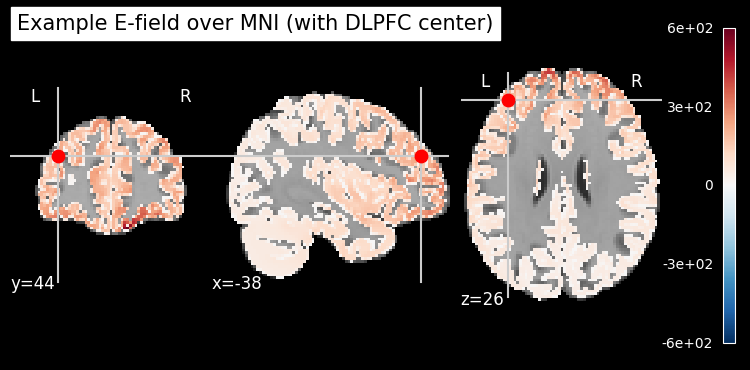

In [4]:

# Plot the example E-field image over MNI (if available); otherwise just show the image
from nilearn.plotting import plot_stat_map

cut_coords = DLPFC_CENTER_MNI

if mni_template is not None:
    # Resample example to MNI for plotting clarity
    try:
        ex_resamp = image.resample_to_img(img, mni_template, interpolation='continuous')
    except Exception:
        ex_resamp = img
    plot_display = plot_stat_map(ex_resamp, bg_img=mni_template, display_mode='ortho', cut_coords=cut_coords,
                            title='Example E-field over MNI (with DLPFC center)')
else:
    plot_display = plot_stat_map(img, display_mode='ortho', cut_coords=cut_coords,
                            title='Example E-field (no MNI background available)')

# Add a marker at the DLPFC center
try:
    plot_display.add_markers([DLPFC_CENTER_MNI], marker_color='red', marker_size=80)
except Exception as e:
    print("Could not add marker:", e)



## Creating a spherical ROI and extracting the mean |E|

We’ll use `NiftiSpheresMasker` to build a spherical ROI centered at our MNI coordinate and compute the **mean** within the sphere.

### Key points
- The sphere is defined in **world space (mm)** using the image’s affine.
- If your volumes are in **MNI space**, an MNI coordinate is appropriate.
- We can optionally provide a **GM mask** to restrict the sphere to GM voxels.
- Because SimNIBS outputs may be zero outside GM, we often **ignore zeros** when averaging.


In [5]:

from nilearn.maskers import NiftiSpheresMasker

# Build masker
masker = NiftiSpheresMasker(
    seeds=[DLPFC_CENTER_MNI],
    radius=SPHERE_RADIUS_MM,
    smoothing_fwhm=SMOOTHING_FWHM,
    standardize=False,
    detrend=False,
    mask_img=OPTIONAL_GM_MASK,
)

# Extract data for the example subject
roi_data = masker.fit_transform(img)  # shape: (n_volumes, n_seeds) -> for 3D input, n_volumes=1
roi_vals = roi_data.ravel()  # one value per seed for 3D data

# By default, that's the mean across all voxels in the sphere (or masked sphere) per seed.
mean_roi = float(roi_vals[0])
print(f"Mean |E| inside DLPFC sphere (radius {SPHERE_RADIUS_MM} mm) for example subject: {mean_roi:.6f}")



Mean |E| inside DLPFC sphere (radius 8 mm) for example subject: 101.983887



### Ignoring zeros robustly

`NiftiSpheresMasker` directly outputs the **mean**. To **ignore zeros**, we’ll build the sphere **mask image** ourselves and then compute the mean over **non‑zero** voxels inside that mask.


In [6]:

from nilearn.image import new_img_like

# Create a binary sphere mask in the example image space
# Approach: create a 3D grid of voxel centers in world coordinates and threshold distance to center

aff = img.affine
inv_aff = np.linalg.inv(aff)

# Build a 3D array of voxel coordinates (world space)
shape = img.shape[:3]
x = np.arange(shape[0])
y = np.arange(shape[1])
z = np.arange(shape[2])
X, Y, Z = np.meshgrid(x, y, z, indexing='ij')
voxel_indices = np.vstack([X.ravel(), Y.ravel(), Z.ravel(), np.ones(X.size)])
world_coords = aff @ voxel_indices
# world_coords[0:3, :] are xyz in mm

center = np.array(list(DLPFC_CENTER_MNI) + [1.0])
center_vox = inv_aff @ center
center_xyz = center[:3]

# Euclidean distances in world space
coords_xyz = world_coords[:3, :].T
dists = np.linalg.norm(coords_xyz - center_xyz, axis=1)
sphere_mask_data = (dists <= SPHERE_RADIUS_MM).astype(float).reshape(shape)

sphere_mask_img = new_img_like(img, sphere_mask_data, affine=aff)

# Compute mean within sphere, ignoring zeros
img_data = img.get_fdata(dtype=float)
sphere_vals = img_data[sphere_mask_data.astype(bool)]
if IGNORE_ZEROS_IN_ROI:
    sphere_vals = sphere_vals[sphere_vals != 0]

mean_roi_ignore0 = float(np.nan) if sphere_vals.size == 0 else float(np.nanmean(sphere_vals))
print(f"Mean |E| inside DLPFC sphere (ignoring zeros): {mean_roi_ignore0:.6f}")


Mean |E| inside DLPFC sphere (ignoring zeros): 131.228806



## Batch processing: loop over all subjects and export CSV

We will:

1. Loop over all matched files in `DATA_DIR`.
2. Compute the mean |E| inside the DLPFC sphere (ignoring zeros if requested).
3. Infer a `subject_id` from the filename (you can adjust the function if your naming is different).
4. Save a **CSV** with columns: `subject_id`, `file`, `mean_e_dlpfc`.


In [ ]:

from pathlib import Path
from IPython.display import display  # Import IPython's display function explicitly

# Helper to compute mean within spherical ROI, with optional GM mask and zero-ignoring

def mean_in_spherical_roi(img, center_mni, radius_mm, ignore_zeros=True, gm_mask_img=None):
    # Build sphere mask in the image space (world distances)
    aff = img.affine
    inv_aff = np.linalg.inv(aff)
    shape = img.shape[:3]

    x = np.arange(shape[0])
    y = np.arange(shape[1])
    z = np.arange(shape[2])
    X, Y, Z = np.meshgrid(x, y, z, indexing='ij')
    voxel_indices = np.vstack([X.ravel(), Y.ravel(), Z.ravel(), np.ones(X.size)])
    world_coords = aff @ voxel_indices

    center = np.array(list(center_mni) + [1.0])
    center_xyz = center[:3]
    coords_xyz = world_coords[:3, :].T
    dists = np.linalg.norm(coords_xyz - center_xyz, axis=1)
    sphere_mask = (dists <= radius_mm).reshape(shape)

    data = img.get_fdata(dtype=float)

    if gm_mask_img is not None:
        try:
            gm_mask_img_res = image.resample_to_img(gm_mask_img, img, interpolation='nearest')
            gm_mask = gm_mask_img_res.get_fdata() > 0
            sphere_mask = sphere_mask & gm_mask
        except Exception as e:
            print("⚠️ Could not apply GM mask:", e)

    vals = data[sphere_mask]
    if ignore_zeros:
        vals = vals[vals != 0]

    if vals.size == 0:
        return np.nan
    return float(np.nanmean(vals))


def guess_subject_id(path):
    name = Path(path).name
    # Extract subject ID: characters before first underscore
    subject_id = name.split('_')[0] if '_' in name else name.split('.')[0]
    # Add "_MNI" suffix if filename contains "MNI" anywhere
    if 'MNI' in name:
        subject_id += '_MNI'
    return subject_id

results = []

# Preload GM mask if provided
_gm_mask_img = None
if OPTIONAL_GM_MASK is not None and os.path.exists(OPTIONAL_GM_MASK):
    _gm_mask_img = image.load_img(OPTIONAL_GM_MASK)
    print("Loaded GM mask:", OPTIONAL_GM_MASK)
elif OPTIONAL_GM_MASK:
    print("⚠️ GM mask path does not exist:", OPTIONAL_GM_MASK)

for f in files:
    try:
        img_i = image.load_img(f)
        mean_i = mean_in_spherical_roi(img_i, DLPFC_CENTER_MNI, SPHERE_RADIUS_MM,
                                       ignore_zeros=IGNORE_ZEROS_IN_ROI,
                                       gm_mask_img=_gm_mask_img)
        results.append({
            'subject_id': guess_subject_id(f),
            'file': os.path.basename(f),
            'mean_e_dlpfc': mean_i,
        })
    except Exception as e:
        print(f"⚠️ Error processing {f}: {e}")

# Save to CSV
if results:
    df = pd.DataFrame(results).sort_values('subject_id').reset_index(drop=True)
    df.to_csv(OUTPUT_CSV, index=False)
    print(f"Saved {len(df)} rows to {OUTPUT_CSV}")
    display(df.head())
else:
    print("⚠️ No results to save. Check your file pattern and parameters.")


Saved 1 rows to efield_DLPFC_roi_means.csv


,subject_id,file,mean_e_dlpfc
0,ernie_1_scalar_MNI_nE,ernie_TDCS_1_scalar_MNI_magnE.nii.gz,131.228806



## QC: visualize the ROI sphere on the template and on a subject

This helps confirm that the sphere is where you expect.


/var/folders/bp/8t84qcf1751_zcnjhfxzxll80000gr/T/ipykernel_97119/2119367972.py:23: FutureWarning: 'force_resample' will be set to 'True' by default in Nilearn 0.13.0.
Use 'force_resample=True' to suppress this warning.
  sphere_on_bg = image.resample_to_img(sphere_mask_img, bg, interpolation='nearest')
/var/folders/bp/8t84qcf1751_zcnjhfxzxll80000gr/T/ipykernel_97119/2119367972.py:23: FutureWarning: From release 0.13.0 onwards, this function will, by default, copy the header of the input image to the output. Currently, the header is reset to the default Nifti1Header. To suppress this warning and use the new behavior, set `copy_header=True`.
  sphere_on_bg = image.resample_to_img(sphere_mask_img, bg, interpolation='nearest')


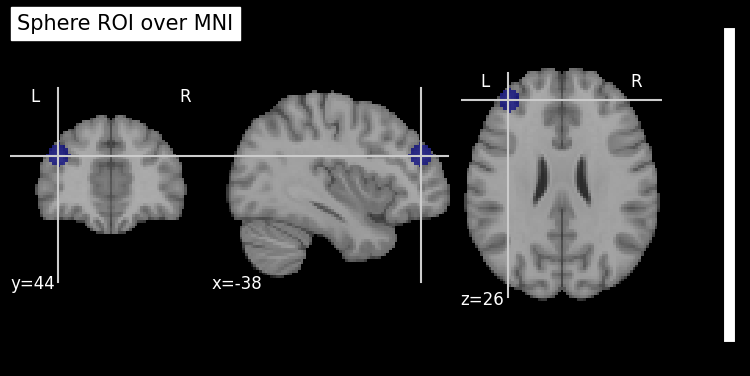

In [8]:

from nilearn.plotting import plot_roi

# Visualize the sphere mask we built on the example subject
# Rebuild the sphere mask quickly

aff = img.affine
shape = img.shape[:3]
x = np.arange(shape[0]); y = np.arange(shape[1]); z = np.arange(shape[2])
X, Y, Z = np.meshgrid(x, y, z, indexing='ij')
voxel_indices = np.vstack([X.ravel(), Y.ravel(), Z.ravel(), np.ones(X.size)])
world_coords = aff @ voxel_indices
center = np.array(list(DLPFC_CENTER_MNI) + [1.0])
center_xyz = center[:3]
coords_xyz = world_coords[:3, :].T
dists = np.linalg.norm(coords_xyz - center_xyz, axis=1)
sphere_mask_data = (dists <= SPHERE_RADIUS_MM).astype(float).reshape(shape)

sphere_mask_img = image.new_img_like(img, sphere_mask_data, affine=aff)

if mni_template is not None:
    bg = mni_template
    try:
        sphere_on_bg = image.resample_to_img(sphere_mask_img, bg, interpolation='nearest')
    except Exception:
        sphere_on_bg = sphere_mask_img
    plot_display = plot_roi(sphere_on_bg, bg_img=bg, title='Sphere ROI over MNI', display_mode='ortho')
else:
    plot_display = plot_roi(sphere_mask_img, bg_img=img, title='Sphere ROI over subject', display_mode='ortho')



## Optional: bilateral DLPFC or multiple seeds

You can average across **multiple spheres** (e.g., left and right DLPFC) by looping over coordinates and computing the mean of means, or by building a combined mask (union of spheres).

Example coordinates:
- Left DLPFC (example): `(-38, 44, 26)`
- Right DLPFC (mirror): `(38, 44, 26)`

To extend this notebook, define `SEEDS = [(-38, 44, 26), (38, 44, 26)]` and compute each sphere’s mean, then average them or report separately.



## Troubleshooting & tips

- **Are images in MNI space?** If your overlay looks misaligned, your images may be in native space. Either normalize to MNI (SPM, FSL, ANTs, fMRIPrep) or map the MNI sphere into native space using the inverse transform.
- **Resolution differences.** Different voxel sizes are OK—`nilearn` handles resampling for plotting; our custom mask builds the sphere in **world mm** so it remains consistent.
- **Empty or all‑zero ROI.** If there are no non‑zero voxels in the sphere (after GM masking or zero‑ignoring), the result is `NaN`. Consider increasing the radius or verifying the seed.
- **Choosing the DLPFC coordinate.** DLPFC is functionally diverse. Pick coordinates justified by your **study design** and **literature** (e.g., BA46/9). You can also test sensitivity by shifting the seed ±5–10 mm.
- **Saving figures.** Any nilearn plot object has a `.savefig('file.png')` method.
- **Reproducibility.** Record your parameters (seed, radius, smoothing) in the CSV filename or in a sidecar README.



## Appendix: What functions did we use?

- `nilearn.image.load_img(path)`: loads a NIfTI as an object that carries data + affine.
- `nilearn.maskers.NiftiSpheresMasker`: defines spherical ROI(s) and extracts summary signals.
- `nilearn.plotting.plot_stat_map(...)`: overlays an image onto a background for QC.
- `nilearn.datasets.load_mni152_template(...)`: convenient MNI template for visuals.
- `numpy` / `pandas`: array math and tidy tables.
- `nibabel`: low‑level NIfTI I/O.

### Next steps
- Replace the spherical ROI with an **anatomical or functional atlas** using `NiftiLabelsMasker`.
- Run **sensitivity analyses** (different radii, bilateral ROIs, different seeds).